# 02 — Carbon pipeline

Produces every published number in the project. The dashboard, the databases
and the report read only what this notebook writes to `results/`:

| File | Contents |
|---|---|
| `results/district_summary.json` | District totals with standard errors and 95% intervals, sensitivity runs, the crop-yield cross-check and caveats |
| `results/model_metrics.json` | Validation of the gap-filling interpolation and of the (secondary) machine-learning experiment, with baselines |
| `results/carbon_cells.csv` | One row per grid cell, keyed by `cell_id`, with the value and where it came from |
| `results/ndvi_monthly.json` | Monthly median NDVI over cells whose NDVI can be attributed |
| `results/fig_*.png` | Figures for the report |

**Two modes.** If `IIRS/Carbon_Stocks/v2/ludhiana_cells_v2.csv` exists (built
by `00_gee_extraction.ipynb`), every cell is observed and totals are a census.
Otherwise the notebook runs the **v1 interim** analysis on the existing exports:

1. Soil values are repaired for unmasked-nodata dilution (`value / w`), or the
   cell is marked no-data. No cell is deleted.
2. District totals come from **design-based estimators**. The 20,000-cell file
   is consistent in every check with a simple random sample of the 66,700-cell
   grid (`01_data_audit`), so survey estimators apply and no predictive model
   is needed. Because bulk density exists for every cell, the mapped soil area
   is known exactly, and the SOC total is the sample stock density (ratio
   estimator) times that known area.
3. Per-cell values for the 46,700 unsampled cells are filled by inverse-distance
   interpolation from the sampled cells, validated by cross-validation. This is
   for the map only; the totals do not depend on it.
4. MOD17 NPP is converted with its documented scale factor and checked against
   an independent crop-yield estimate.
5. A random-forest experiment is reported against baselines as a methods
   result. It is not used to produce any number.

In [1]:
import json
import sys
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import config as C
import estimators as E

C.RESULTS.mkdir(exist_ok=True)
V2_FILE = C.DATA / "v2" / "ludhiana_cells_v2.csv"
MODE = "v2-census" if V2_FILE.exists() else "v1-interim"
RUN_DATE = str(date.today())
print("Mode:", MODE)

Mode: v1-interim


## 1. Load the grid and the sample

In [2]:
if MODE == "v1-interim":
    grid = C.load_grid()                      # 66,700 cells, keyed, area, soil QC
    sample = C.load_samples()                 # 20,000 cells: SOC (g/kg, raw), NPP DN
    grid = grid.merge(sample, on="cell_id", how="left", validate="one_to_one")
    grid["sampled"] = grid["cell_id"].isin(sample["cell_id"])
    N, n = len(grid), int(grid["sampled"].sum())

    # Repair diluted soil bands for every cell (BD, sand, clay exist grid-wide; SOC only where sampled)
    for raw, out in [("bd_gcm3", "bd_rec"), ("sand_pct", "sand_rec"), ("clay_pct", "clay_rec"), ("soc_gkg_raw", "soc_rec")]:
        grid[out] = C.undilute(grid[raw], grid["w_soil"])

    print(f"grid cells {N:,} | sampled {n:,} ({n / N:.1%})")
    print("soil status:", grid["soil_status"].value_counts().to_dict())
    print(f"grid area {grid.cell_area_ha.sum():,.0f} ha = {grid.cell_area_ha.sum() / C.OFFICIAL_AREA_HA:.1%} of the Census district area")
else:
    grid = pd.read_csv(V2_FILE)
    C.assert_unique(grid)
    geo = C.lattice_geometry(grid["grid_row"], grid["grid_col"])
    grid[["lon", "lat", "WKT"]] = geo.to_numpy()
    grid["lon"], grid["lat"] = grid["lon"].astype(float), grid["lat"].astype(float)
    grid["agri_class"] = (grid["cropland_frac"] >= 0.5).astype(int)
    grid["Ag/NonAg_m"] = grid["cropland_frac"]
    grid["DEM_mean"], grid["Slope_mean"] = grid["dem_m"], grid["slope_deg"]
    grid["soil_status"] = np.select([grid["soil_valid_frac"] >= 0.999, grid["soil_valid_frac"] > 0], ["full", "partial"], "nodata")
    # Totals are restricted to the district: weight each cell by the share inside the boundary
    grid["cell_area_full_ha"] = grid["cell_area_ha"]
    grid["cell_area_ha"] = grid["cell_area_ha"] * grid["in_district_frac"]
    grid["in_district_frac"] = 1.0          # already applied to cell_area_ha
    print(f"v2 cells {len(grid):,} | area inside boundary {grid.cell_area_ha.sum():,.0f} ha")

grid cells 66,700 | sampled 20,000 (30.0%)
soil status: {'full': 59089, 'partial': 4958, 'nodata': 2653}
grid area 356,894 ha = 94.7% of the Census district area


## 2. Soil organic carbon stock (0–30 cm)

Per cell, stock density over its valid soil = SOC × BD × 30 / 10 (tC/ha), and
the cell's stock = density × valid fraction *w* × cell area. For a partially
diluted cell this equals SOC_diluted × BD_REF × 3 × area, so *w* cancels and
every diluted cell can enter the totals without instability. Cells with no
valid soil (mostly built-up land and water) contribute no soil area and no
stock; they are reported, not zero-filled into a mean.

**Headline estimator.** Mapped soil area A = Σ *w* × area is known for all
66,700 cells, because bulk density exists everywhere. The stock is the sample
ratio R = Σ stock / Σ soil area times A, with SE = A × SE(R).

In [3]:
if MODE == "v1-interim":
    s = grid[grid["sampled"]].copy()
    s["dens"] = C.soc_stock_tc_ha(s["soc_rec"], s["bd_rec"])                 # tC per ha of valid soil
    s["y_stock"] = (s["dens"] * s["w_soil"] * s["cell_area_ha"]).fillna(0)  # tC in the cell
    s["a_soil"] = s["w_soil"] * s["cell_area_ha"]

    A_soil = float((grid["w_soil"] * grid["cell_area_ha"]).sum())           # census, every cell
    stock = E.ratio_total(s["y_stock"], s["a_soil"], N, A_soil)
    density = E.srs_ratio(s["y_stock"], s["a_soil"], N)

    def variant(est):
        return E.scale(est, 1e-6)

    full_only = np.where(s["soil_status"] == "full", s["y_stock"], 0)
    reliable_only = np.where(s["soil_status"].eq("full") | s["w_reliable"], s["y_stock"], 0)
    raw = (C.soc_stock_tc_ha(s["soc_gkg_raw"], s["bd_gcm3"]) * s["cell_area_ha"]).fillna(0)
    sensitivity_soil = [
        {"variant": "Headline: ratio estimator x known soil area, all diluted cells repaired", **variant(stock)},
        {"variant": "Expansion estimator (ignores the known soil area)", **variant(E.srs_total(s["y_stock"], N))},
        {"variant": "Only partial cells with w >= 0.5 repaired, rest dropped", **variant(E.srs_total(reliable_only, N))},
        {"variant": "All partially diluted cells dropped", **variant(E.srs_total(full_only, N))},
        {"variant": "No quality control (zeros averaged in, as in v1)", **variant(E.srs_total(raw, N))},
    ]
    soil_out = {
        "stock_mtc": E.scale(stock, 1e-6),
        "soil_area_ha": {"estimate": round(A_soil), "se": 0.0, "ci95": None, "n": int(N), "note": "census of every cell"},
        "mean_density_tc_ha": E.scale(density, 1, 3),
        "depth_cm": C.SOC_DEPTH_CM,
        "cells": grid["soil_status"].value_counts().to_dict(),
        "nodata_non_agricultural_share": round(float((grid.loc[grid.soil_status == "nodata", "agri_class"] == 0).mean()), 3),
        "method": "Ratio estimator from a random sample of 20,000 of 66,700 cells times the census soil area; diluted soil values repaired by value / w",
        "interval_covers": "sampling error only; see caveats for known biases that are not in the interval",
        "sensitivity": sensitivity_soil,
    }
else:
    tot = E.census_totals(grid)
    soil_out = {
        "stock_mtc": {"estimate": round(tot["soil_stock_tc"] / 1e6, 4), "se": None, "ci95": None},
        "soil_area_ha": {"estimate": round(tot["soil_area_ha"])},
        "mean_density_tc_ha": {"estimate": round(tot["soil_stock_tc"] / tot["soil_area_ha"], 3)},
        "depth_cm": C.SOC_DEPTH_CM,
        "method": "Census of every cell; SoilGrids 0-30 cm thickness-weighted, coarse fragments removed, area inside boundary",
    }
    check_col = f"in_{C.BOUNDARY_CHECK}"
    if check_col in grid:
        alt = E.census_totals(grid.assign(cell_area_ha=grid["cell_area_full_ha"], in_district_frac=grid[check_col]))
        soil_out["sensitivity"] = [
            {"variant": f"Boundary: {C.BOUNDARY_DEFAULT} (headline)", "estimate": round(tot["soil_stock_tc"] / 1e6, 4), "area_ha": round(tot["area_in_district_ha"])},
            {"variant": f"Boundary: {C.BOUNDARY_CHECK}", "estimate": round(alt["soil_stock_tc"] / 1e6, 4), "area_ha": round(alt["area_in_district_ha"])},
        ]
        npp_alt_mtc = round(alt["npp_flux_tc_yr"] / 1e6, 4)
    ok = grid["soil_valid_frac"] >= 0.999
    soil_out["ocs_crosscheck_ratio"] = round(float(
        (C.soc_stock_tc_ha(grid.loc[ok, "soc_030"], grid.loc[ok, "bdod_030"], 30, grid.loc[ok, "cfvo_030"] / 100)
         / grid.loc[ok, "ocs_030_t_ha"]).median()), 3)

print(json.dumps(soil_out, indent=2, default=str))

{
  "stock_mtc": {
    "estimate": 4.5488,
    "se": 0.0017,
    "ci95": [
      4.5455,
      4.552
    ],
    "n": 20000
  },
  "soil_area_ha": {
    "estimate": 329814,
    "se": 0.0,
    "ci95": null,
    "n": 66700,
    "note": "census of every cell"
  },
  "mean_density_tc_ha": {
    "estimate": 13.792,
    "se": 0.005,
    "ci95": [
      13.782,
      13.802
    ],
    "n": 20000
  },
  "depth_cm": 30,
  "cells": {
    "full": 59089,
    "partial": 4958,
    "nodata": 2653
  },
  "nodata_non_agricultural_share": 0.983,
  "method": "Ratio estimator from a random sample of 20,000 of 66,700 cells times the census soil area; diluted soil values repaired by value / w",
  "interval_covers": "sampling error only; see caveats for known biases that are not in the interval",
  "sensitivity": [
    {
      "variant": "Headline: ratio estimator x known soil area, all diluted cells repaired",
      "estimate": 4.5488,
      "se": 0.0017,
      "ci95": [
        4.5455,
        4.552
      ]

## 3. MOD17 NPP flux

`Agricultur` holds MOD17A3HGF DN. Flux (tC/ha/yr) = DN × 0.0001 kgC/m² × 10 =
DN / 1000. Negative values are kept: they are the product's own output, and
clipping them to zero would bias the total upwards. Cells where the product
has no value (82% non-agricultural) are outside its domain, not zero.

In [4]:
if MODE == "v1-interim":
    s["npp_valid"] = s["npp_dn"].notna()
    s["flux_tc_ha_yr"] = s["npp_dn"] * C.NPP_DN_TO_TC_HA_YR
    s["y_flux"] = (s["flux_tc_ha_yr"] * s["cell_area_ha"]).fillna(0)
    s["a_flux"] = np.where(s["npp_valid"], s["cell_area_ha"], 0.0)

    flux = E.srs_total(s["y_flux"], N)
    flux_area = E.srs_total(s["a_flux"], N)
    flux_rate = E.srs_ratio(s["y_flux"], s["a_flux"], N)
    agri = s["agri_class"] == 1

    sensitivity_npp = [
        {"variant": "Headline: DN / 1000, negatives kept", **E.scale(flux, 1e-6)},
        {"variant": "Negatives clipped to zero", **E.scale(E.srs_total((s["flux_tc_ha_yr"].clip(lower=0) * s["cell_area_ha"]).fillna(0), N), 1e-6)},
        {"variant": "Agricultural cells only", **E.scale(E.srs_total(np.where(agri, s["y_flux"], 0), N), 1e-6)},
        {"variant": "Old conversion DN / 100 (wrong by 10x), negatives clipped", **E.scale(E.srs_total((s["npp_dn"].clip(lower=0) / 100 * s["cell_area_ha"]).fillna(0), N), 1e-6)},
    ]
    npp_out = {
        "flux_mtc_per_year": E.scale(flux, 1e-6),
        "domain_area_ha": E.scale(flux_area, 1, 0),
        "mean_rate_tc_ha_yr": E.scale(flux_rate, 1, 3),
        "mean_rate_agricultural_tc_ha_yr": round(float(s.loc[agri & s.npp_valid, "flux_tc_ha_yr"].mean()), 3),
        "negative_share_agricultural": round(float((s.loc[agri & s.npp_valid, "npp_dn"] < 0).mean()), 3),
        "conversion": C.AG_FORMULA,
        "method": "Expansion estimator from the same random sample; MOD17 DN scaled per product specification",
        "sensitivity": sensitivity_npp,
    }
else:
    npp_out = {
        "flux_mtc_per_year": {"estimate": round(tot["npp_flux_tc_yr"] / 1e6, 4), "se": None, "ci95": None},
        "domain_area_ha": {"estimate": round(tot["npp_area_ha"])},
        "mean_rate_tc_ha_yr": {"estimate": round(tot["npp_flux_tc_yr"] / tot["npp_area_ha"], 3)},
        "conversion": "npp_gc_m2_yr / 100 (scaled inside Earth Engine)",
        "method": "Census of every cell, area inside boundary",
    }
    if "npp_alt_mtc" in globals():
        npp_out["sensitivity"] = [
            {"variant": f"Boundary: {C.BOUNDARY_DEFAULT} (headline)", "estimate": round(tot["npp_flux_tc_yr"] / 1e6, 4)},
            {"variant": f"Boundary: {C.BOUNDARY_CHECK}", "estimate": npp_alt_mtc}]
print(json.dumps(npp_out, indent=2, default=str))

{
  "flux_mtc_per_year": {
    "estimate": 0.2952,
    "se": 0.0025,
    "ci95": [
      0.2903,
      0.3001
    ],
    "n": 20000
  },
  "domain_area_ha": {
    "estimate": 304063.0,
    "se": 750.0,
    "ci95": [
      302592.0,
      305533.0
    ],
    "n": 20000
  },
  "mean_rate_tc_ha_yr": {
    "estimate": 0.971,
    "se": 0.008,
    "ci95": [
      0.956,
      0.986
    ],
    "n": 20000
  },
  "mean_rate_agricultural_tc_ha_yr": 0.946,
  "negative_share_agricultural": 0.198,
  "conversion": "NPP flux (tC/ha/yr) = MOD17 DN x 0.0001 kgC/m2 x 10 = DN / 1000",
  "method": "Expansion estimator from the same random sample; MOD17 DN scaled per product specification",
  "sensitivity": [
    {
      "variant": "Headline: DN / 1000, negatives kept",
      "estimate": 0.2952,
      "se": 0.0025,
      "ci95": [
        0.2903,
        0.3001
      ],
      "n": 20000
    },
    {
      "variant": "Negatives clipped to zero",
      "estimate": 0.361,
      "se": 0.0018,
      "ci95": [
 

### Independent check: crop NPP from harvested yield

Ludhiana is a rice–wheat double-crop district. Carbon in harvested grain,
residue and roots can be computed from reported yields with IPCC (2019)
Vol. 4 Table 11.1a factors. This is a lower bound on true NPP.

| Input | Wheat | Rice (paddy) | Source |
|---|---|---|---|
| Area (ha) | 245,200 (2023-24) | 256,600 (2024) | Tribune India, 23 Apr 2024; 5 Jan 2025 (district agriculture department figures) |
| Yield (t/ha, as harvested) | 5.000 | 7.014 | same |
| Dry-matter fraction | 0.89 | 0.89 | IPCC 2019 Table 11.1a |
| Above-ground residue : yield | 1.3 | 1.4 | IPCC 2019 Table 11.1a (R_AG) |
| Root : shoot | 0.23 ± 41% | 0.16 ± 35% | IPCC 2019 Table 11.1a (RS) |
| Carbon fraction of dry matter | 0.42–0.47 | 0.42–0.47 | assumption, uniform range |

The wheat yield is a preliminary in-season figure; a 10% relative SD is used
for both yields and 20% for the residue ratios.

In [5]:
CROPS = {
    "wheat": {"area_ha": 245_200, "yield_t_ha": 5.000, "yield_rel_sd": 0.10, "dry_frac": 0.89,
              "residue_ratio": 1.3, "residue_rel_sd": 0.20, "root_shoot": 0.23, "root_shoot_rel_sd": 0.41},
    "rice":  {"area_ha": 256_600, "yield_t_ha": 7.014, "yield_rel_sd": 0.10, "dry_frac": 0.89,
              "residue_ratio": 1.4, "residue_rel_sd": 0.20, "root_shoot": 0.16, "root_shoot_rel_sd": 0.35},
}
crop = E.crop_npp_monte_carlo(CROPS, seed=C.RANDOM_STATE)
mod17 = npp_out["flux_mtc_per_year"]["estimate"]
crop["mod17_over_crop_ratio"] = round(mod17 / crop["total_mtc_median"], 3)
# Area-independent view: per hectare of double-cropped land, one year
crop["crop_tc_ha_yr_double_cropped"] = round(sum(v["tc_ha_median"] for v in crop["per_crop"].values()), 2)
if MODE == "v1-interim":
    crop["mod17_agricultural_tc_ha_yr"] = npp_out["mean_rate_agricultural_tc_ha_yr"]
crop["comparability_note"] = ("MOD17 is totalled over the grid's product domain (the grid covers ~95% of the district) "
                              "while crop areas are district-wide; the MOD17 year in v1 is unrecorded while yields are "
                              "2023-24 (wheat) and 2024 (paddy). Neither changes the order-of-magnitude gap.")
crop["inputs"] = CROPS
print(f"Crop-yield NPP (rice + wheat, lower bound): {crop['total_mtc_median']:.2f} MtC/yr "
      f"(90% range {crop['total_mtc_p05_p95'][0]:.2f}-{crop['total_mtc_p05_p95'][1]:.2f})")
for k, v in crop["per_crop"].items():
    print(f"  {k:5s} {v['tc_ha_median']:.2f} tC/ha per season (90%: {v['tc_ha_p05_p95'][0]:.2f}-{v['tc_ha_p05_p95'][1]:.2f})")
print(f"MOD17, correctly scaled: {mod17:.3f} MtC/yr = {crop['mod17_over_crop_ratio']:.1%} of the crop-yield lower bound")
print(f"Per hectare per year: crops >= {crop['crop_tc_ha_yr_double_cropped']} tC/ha/yr on double-cropped land; "
      f"MOD17 on agricultural cells {crop.get('mod17_agricultural_tc_ha_yr')} tC/ha/yr")

Crop-yield NPP (rice + wheat, lower bound): 3.34 MtC/yr (90% range 2.70-4.07)
  wheat 5.55 tC/ha per season (90%: 4.10-7.26)
  rice  7.66 tC/ha per season (90%: 5.72-9.97)
MOD17, correctly scaled: 0.295 MtC/yr = 8.8% of the crop-yield lower bound
Per hectare per year: crops >= 13.2 tC/ha/yr on double-cropped land; MOD17 on agricultural cells 0.946 tC/ha/yr


**Reading this result.** Correctly scaled MOD17 captures roughly a tenth of the
carbon that demonstrably passes through Ludhiana's crops each year, and it
reports negative annual NPP for about a fifth of agricultural cells. MOD17 is
therefore not fit for estimating crop carbon flux in this irrigated
double-cropped landscape. The old pipeline's number looked plausible only
because a second error — skipping the scale factor — multiplied it by ten. The
unit conversion is fixed by the product specification and must not be
"corrected" to match expectations; the product is what should be replaced (for
example by the yield-based estimate above, or a crop-specific light-use-
efficiency model).

## 4. Per-cell map

Every cell gets a value and a `*_source` label. In v1, unsampled cells are
filled by inverse-distance weighting (k = 8, power 2) from sampled cells. The
validation uses random folds because the unsampled cells are interleaved with
the sample at the same spacing.

In [6]:
interp_metrics = {}
if MODE == "v1-interim":
    xy_all = E.to_metres(grid["lon"], grid["lat"])
    samp = grid["sampled"].to_numpy()

    # SOC: interpolate repaired values from sampled cells whose repair is reliable (w >= 0.5)
    soc_src = samp & grid["soc_rec"].notna().to_numpy() & (grid["soil_status"].eq("full") | grid["w_reliable"]).to_numpy()
    interp_metrics["soc_gkg"] = E.idw_cv(xy_all[soc_src], grid.loc[soc_src, "soc_rec"])
    grid["soc_gkg"] = grid["soc_rec"]
    fill = ~samp & (grid["soil_status"] != "nodata").to_numpy()
    grid.loc[fill, "soc_gkg"] = E.idw(xy_all[soc_src], grid.loc[soc_src, "soc_rec"], xy_all[fill])
    grid["soc_source"] = np.select([grid["soil_status"] == "nodata", samp], ["no soil data", "observed"], "interpolated")

    # NPP: interpolate the validity mask and the DN, from sampled cells
    npp_ok = samp & grid["npp_dn"].notna().to_numpy()
    interp_metrics["npp_gc_m2_yr"] = E.idw_cv(xy_all[npp_ok], grid.loc[npp_ok, "npp_dn"] * C.NPP_DN_TO_GC_M2_YR)
    valid_p = E.idw(xy_all[samp], grid.loc[samp, "npp_dn"].notna().astype(float), xy_all[~samp])
    grid["npp_dn_map"] = grid["npp_dn"]
    est = E.idw(xy_all[npp_ok], grid.loc[npp_ok, "npp_dn"], xy_all[~samp])
    grid.loc[~samp, "npp_dn_map"] = np.where(valid_p >= 0.5, est, np.nan)
    grid["npp_source"] = np.where(samp, np.where(grid["npp_dn"].notna(), "observed", "outside MOD17 domain"),
                                  np.where(grid["npp_dn_map"].notna(), "interpolated", "outside MOD17 domain"))

    grid["bd_gcm3_rec"] = grid["bd_rec"]
    grid["soc_stock_tc_ha"] = C.soc_stock_tc_ha(grid["soc_gkg"], grid["bd_rec"])
    grid["npp_flux_tc_ha_yr"] = grid["npp_dn_map"] * C.NPP_DN_TO_TC_HA_YR
else:
    grid["soc_gkg"], grid["bd_gcm3_rec"] = grid["soc_030"], grid["bdod_030"]
    grid["w_soil"] = grid["soil_valid_frac"]
    grid["soc_stock_tc_ha"] = C.soc_stock_tc_ha(grid["soc_030"], grid["bdod_030"], 30, grid["cfvo_030"] / 100)
    grid["npp_flux_tc_ha_yr"] = grid["npp_gc_m2_yr"] / 100
    grid["soc_source"] = np.where(grid["soc_030"].notna(), "observed", "no soil data")
    grid["npp_source"] = np.where(grid["npp_gc_m2_yr"].notna(), "observed", "outside MOD17 domain")

grid["soc_stock_tc"] = (grid["soc_stock_tc_ha"] * grid["w_soil"] * grid["cell_area_ha"]).fillna(0)
grid["npp_flux_tc_yr"] = (grid["npp_flux_tc_ha_yr"] * grid["cell_area_ha"]).fillna(0)

for k, m in interp_metrics.items():
    print(f"IDW {k:8s} R2 {m['r2']:.3f}  RMSE {m['rmse']:.3f}  MAE {m['mae']:.3f}  bias {m['bias']:+.4f}  (n={m['n']:,})")
print(f"\nmap sum, soil stock: {grid.soc_stock_tc.sum() / 1e6:.4f} MtC   (headline: {soil_out['stock_mtc']['estimate']})")
print(f"map sum, NPP flux:   {grid.npp_flux_tc_yr.sum() / 1e6:.4f} MtC/yr (headline: {npp_out['flux_mtc_per_year']['estimate']})")

IDW soc_gkg  R2 0.808  RMSE 0.084  MAE 0.059  bias -0.0010  (n=18,522)
IDW npp_gc_m2_yr R2 0.598  RMSE 77.620  MAE 51.709  bias +0.0230  (n=17,038)

map sum, soil stock: 4.5491 MtC   (headline: 4.5488)
map sum, NPP flux:   0.3077 MtC/yr (headline: 0.2952)


The map sums are a consistency check, not the estimate: totals always come from
the design-based estimator. The soil map sum falls inside its interval. The NPP
map sum runs a few per cent high because inverse-distance weighting smooths a
field that mixes positive and negative values, pulling isolated negative cells
towards their positive neighbours.

In [7]:
if MODE == "v1-interim":
    for name, mapped, est in [("soil stock (MtC)", grid.soc_stock_tc.sum() / 1e6, soil_out["stock_mtc"]),
                              ("NPP flux (MtC/yr)", grid.npp_flux_tc_yr.sum() / 1e6, npp_out["flux_mtc_per_year"])]:
        lo, hi = est["ci95"]
        print(f"{name:18s} map {mapped:.4f} | design {est['estimate']} [{lo}, {hi}] | "
              f"{'inside' if lo <= mapped <= hi else 'outside by %+.1f%%' % (100 * (mapped / est['estimate'] - 1))}")

soil stock (MtC)   map 4.5491 | design 4.5488 [4.5455, 4.552] | inside
NPP flux (MtC/yr)  map 0.3077 | design 0.2952 [0.2903, 0.3001] | outside by +4.2%


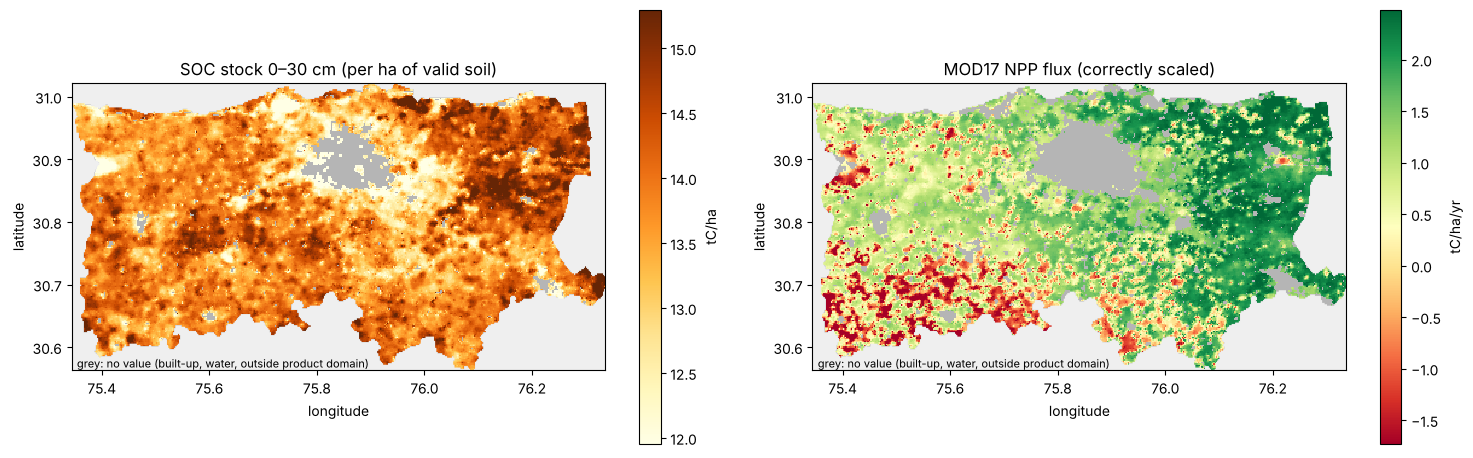

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6.5))
r0, c0 = grid["grid_row"].min(), grid["grid_col"].min()
shape = (grid["grid_row"].max() - r0 + 1, grid["grid_col"].max() - c0 + 1)
extent = [c0 * C.GRID_STEP_DEG, (c0 + shape[1]) * C.GRID_STEP_DEG, r0 * C.GRID_STEP_DEG, (r0 + shape[0]) * C.GRID_STEP_DEG]
for a, col, title, cmap, unit in [
    (ax[0], "soc_stock_tc_ha", "SOC stock 0–30 cm (per ha of valid soil)", "YlOrBr", "tC/ha"),
    (ax[1], "npp_flux_tc_ha_yr", "MOD17 NPP flux (correctly scaled)", "RdYlGn", "tC/ha/yr"),
]:
    img = np.full(shape, np.nan)
    img[grid["grid_row"] - r0, grid["grid_col"] - c0] = grid[col]
    outside = np.ones(shape, bool)
    outside[grid["grid_row"] - r0, grid["grid_col"] - c0] = False
    cm = plt.get_cmap(cmap).copy(); cm.set_bad("#b5b5b5")
    v = grid[col].dropna()
    im = a.imshow(np.ma.masked_invalid(img), origin="lower", extent=extent, cmap=cm, interpolation="nearest",
                  vmin=np.percentile(v, 2), vmax=np.percentile(v, 98))
    a.imshow(np.ma.masked_where(~outside, np.ones(shape)), origin="lower", extent=extent, cmap="Greys", vmin=0, vmax=8)
    a.set_title(title); a.set_aspect(1 / np.cos(np.radians(30.8))); a.set_xlabel("longitude"); a.set_ylabel("latitude")
    plt.colorbar(im, ax=a, shrink=0.7, label=unit)
    a.text(0.01, 0.01, "grey: no value (built-up, water, outside product domain)", transform=a.transAxes, fontsize=8)
plt.tight_layout(); plt.savefig(C.RESULTS / "fig_maps.png", dpi=130); plt.show()

## 5. Machine-learning experiment (methods result, not used for any number)

Random forest under 8 × 8 spatial-block cross-validation, on undiluted cells
only, against two baselines: the training-fold mean, and longitude/latitude
alone. Position-proxy climate layers are excluded from the NPP model. Feature
importance is permutation importance measured on held-out spatial folds.

In [9]:
def spatial_eval(d, feats, target):
    X, y = d[feats].to_numpy(dtype=float), d[target].to_numpy(dtype=float)
    groups = C.spatial_blocks(d["lon"], d["lat"])
    rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=C.RANDOM_STATE)
    pred, base, coord = np.empty_like(y), np.empty_like(y), np.empty_like(y)
    imp = np.zeros(len(feats))
    XY = d[["lon", "lat"]].to_numpy()
    for tr, te in GroupKFold(C.N_FOLDS).split(X, y, groups):
        m = rf.fit(X[tr], y[tr]); pred[te] = m.predict(X[te])
        imp += permutation_importance(m, X[te], y[te], n_repeats=3, random_state=C.RANDOM_STATE, n_jobs=-1).importances_mean
        base[te] = y[tr].mean()
        coord[te] = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, n_jobs=-1,
                                          random_state=C.RANDOM_STATE).fit(XY[tr], y[tr]).predict(XY[te])
    score = lambda p, name: {"model": name, "r2": round(r2_score(y, p), 4),
                             "rmse": round(mean_squared_error(y, p) ** 0.5, 4), "mae": round(mean_absolute_error(y, p), 4)}
    imp = pd.Series(imp / C.N_FOLDS, index=feats).sort_values(ascending=False)
    return {"n": int(len(y)), "target_sd": round(float(y.std()), 4),
            "validation": f"{C.N_FOLDS}-fold GroupKFold over {C.N_BLOCKS}x{C.N_BLOCKS} geographic blocks",
            "models": [score(pred, "Random forest"), score(coord, "Coordinates only"), score(base, "Training mean")],
            "permutation_importance": [{"feature": k, "importance": round(float(v), 4)} for k, v in imp.items()]}

if MODE == "v1-interim":
    ml = grid[grid["sampled"] & (grid["soil_status"] == "full")].copy()
    SOC_FEATS = ["agri_class", "DEM_mean", "Slope_mean", "sand_rec", "clay_rec", "bd_rec"]
    soc_ml = spatial_eval(ml, SOC_FEATS, "soc_rec")
    soc_ml["unit"] = "g/kg"

    nd = C.load_ndvi(grid)
    npp_ml_df = grid[grid["sampled"] & grid["npp_dn"].notna()].merge(nd, on="cell_id", how="left")
    npp_ml_df["npp_gc_m2_yr"] = npp_ml_df["npp_dn"] * C.NPP_DN_TO_GC_M2_YR
    NPP_FEATS = ["agri_class", "DEM_mean", "Slope_mean", "Kharif_pea", "Rabi_Peak_", "Kharif_Lud", "NDWI_Rabi_"] + C.NDVI_COLS
    npp_ml = spatial_eval(npp_ml_df, NPP_FEATS, "npp_gc_m2_yr")
    npp_ml["unit"] = "gC/m2/yr"
    npp_ml["excluded_position_proxies"] = C.POSITION_PROXIES

    for name, r in [("SOC", soc_ml), ("NPP", npp_ml)]:
        print(f"\n{name} (n={r['n']:,}, target sd {r['target_sd']} {r['unit']})")
        print(pd.DataFrame(r["models"]).to_string(index=False))
        print("top importance:", [(d["feature"], d["importance"]) for d in r["permutation_importance"][:5]])
else:
    soc_ml = npp_ml = None
    print("v2 census mode: no gap-filling or model is needed for any number.")


SOC (n=17,691, target sd 0.1872 g/kg)
           model      r2   rmse    mae
   Random forest  0.2000 0.1674 0.1277
Coordinates only  0.1726 0.1703 0.1283
   Training mean -0.0061 0.1878 0.1438
top importance: [('bd_rec', 0.2081), ('DEM_mean', 0.1459), ('sand_rec', 0.1444), ('clay_rec', 0.1264), ('Slope_mean', 0.0528)]

NPP (n=17,038, target sd 122.3874 gC/m2/yr)
           model      r2     rmse     mae
   Random forest  0.3388  99.5158 78.6874
Coordinates only  0.3184 101.0448 78.2218
   Training mean -0.0139 123.2355 94.4833
top importance: [('DEM_mean', 0.339), ('NDVI_Aug24', 0.0923), ('Slope_mean', 0.0702), ('NDVI_Oct24', 0.0335), ('Kharif_Lud', 0.0211)]


## 6. Write results

In [10]:
prev = {"soil_stock_mtc": 4.3554, "npp_flux_mtc_per_year": 3.7085, "soc_r2_spatial": 0.9492,
        "npp_r2_spatial": 0.4226, "cells": 64545,
        "why_superseded": "SOC model learned unmasked-nodata dilution; MOD17 scale factor skipped; 2,155 real cells deleted by Grid_ID de-duplication"}

caveats = [
    "The confidence intervals cover sampling error only. Known biases outside them: unrecorded SoilGrids depth interval, no coarse-fragment correction, grid covering about 95% of the district, and cells with BD 1.40-1.50 treated as undiluted.",
    "SOC values are SoilGrids 2.0 model predictions, not field measurements; SoilGrids' own uncertainty is not yet propagated (quantile layers are not on Earth Engine).",
    "The depth interval behind the v1 SOC export is not recorded; v2 uses a thickness-weighted 0-30 cm.",
    "Coarse fragments are not removed in v1 (v2 removes them using SoilGrids cfvo).",
    "The grid covers {:.1%} of the Census 2011 district area and is not clipped to an official boundary.".format(grid["cell_area_ha"].sum() / C.OFFICIAL_AREA_HA),
    "MOD17 NPP captures about {:.0%} of the crop-yield lower bound and is negative in about a fifth of agricultural cells; it is not fit for crop carbon flux here.".format(crop["mod17_over_crop_ratio"]),
    "Soil stock (tC) and NPP flux (tC/yr) have different dimensions and are never summed.",
    "Neither figure is a carbon-credit quantity: no baseline, additionality, permanence or field verification.",
]
if MODE == "v2-census":
    caveats = [c for c in caveats if "v1" not in c and "Coarse" not in c and "grid covers" not in c and "intervals cover" not in c]

summary = {
    "mode": MODE, "run_date": RUN_DATE, "status": "provisional" if MODE == "v1-interim" else "census",
    "district": "Ludhiana, Punjab, India",
    "grid": {"cells": int(len(grid)), "area_ha": round(float(grid["cell_area_ha"].sum()), 1),
             "official_area_ha": C.OFFICIAL_AREA_HA,
             "coverage_of_official_area": round(float(grid["cell_area_ha"].sum() / C.OFFICIAL_AREA_HA), 4),
             "sampled_cells": int(grid["sampled"].sum()) if "sampled" in grid else None,
             "agri_cells": int((grid["agri_class"] == 1).sum()) if "agri_class" in grid else None},
    "soil": soil_out, "npp": npp_out, "crop_yield_crosscheck": crop,
    "formulas": {"soil": C.BG_FORMULA, "npp": C.AG_FORMULA},
    "previous_published": prev, "caveats": caveats,
}
metrics = {"mode": MODE, "run_date": RUN_DATE, "interpolation": interp_metrics, "soc_experiment": soc_ml, "npp_experiment": npp_ml}

# Monthly NDVI summary for the dashboard (cells whose NDVI can be attributed)
if MODE == "v1-interim":
    nd_all = C.load_ndvi(grid)
else:
    nd_all = grid[["cell_id"] + [c for c in grid.columns if c.startswith("NDVI_")]]
season = {"Jun": "Kharif", "Jul": "Kharif", "Aug": "Kharif", "Sep": "Kharif", "Oct": "Kharif",
          "Nov": "Rabi", "Dec": "Rabi", "Jan": "Rabi", "Feb": "Rabi", "Mar": "Rabi", "Apr": "Rabi", "May": "Fallow"}
ndvi_cols = [c for c in nd_all.columns if c.startswith("NDVI_")]
ndvi_monthly = [{"month": f"{c[5:8]} {c[8:]}", "sort_order": i, "season": season.get(c[5:8], ""),
                 "median_ndvi": round(float(nd_all[c].median()), 4),
                 "cells_with_value": int(nd_all[c].notna().sum()),
                 "missing_share": round(float(nd_all[c].isna().mean()), 4)}
                for i, c in enumerate(ndvi_cols)]
(C.RESULTS / "ndvi_monthly.json").write_text(json.dumps(ndvi_monthly, indent=2))

(C.RESULTS / "district_summary.json").write_text(json.dumps(summary, indent=2, default=float))
(C.RESULTS / "model_metrics.json").write_text(json.dumps(metrics, indent=2, default=float))

keep = ["cell_id", "Grid_ID", "grid_row", "grid_col", "lon", "lat", "cell_area_ha", "agri_class", "Ag/NonAg_m",
        "DEM_mean", "Slope_mean", "soil_status", "w_soil", "w_reliable", "bd_gcm3_rec", "soc_gkg", "soc_source",
        "soc_stock_tc_ha", "soc_stock_tc", "npp_flux_tc_ha_yr", "npp_source", "npp_flux_tc_yr", "WKT"]
out = grid[[c for c in keep if c in grid.columns]]
C.assert_unique(out).to_csv(C.RESULTS / "carbon_cells.csv", index=False, float_format="%.5g")
print("Wrote district_summary.json, model_metrics.json, ndvi_monthly.json, carbon_cells.csv", f"({len(out):,} cells)")
print(f"\nSOC stock  : {soil_out['stock_mtc']['estimate']} MtC  95% CI {soil_out['stock_mtc'].get('ci95')}")
print(f"NPP flux   : {npp_out['flux_mtc_per_year']['estimate']} MtC/yr  95% CI {npp_out['flux_mtc_per_year'].get('ci95')}")

Wrote district_summary.json, model_metrics.json, ndvi_monthly.json, carbon_cells.csv (66,700 cells)

SOC stock  : 4.5488 MtC  95% CI [4.5455, 4.552]
NPP flux   : 0.2952 MtC/yr  95% CI [0.2903, 0.3001]
